# 09 — High-order Shack–Hartmann AO / NIR PSF performance demonstrator

This notebook upgrades the previous low-order Zernike-modal AO examples into a **higher-order actuator-space adaptive-optics closed loop** for a 10 m-class telescope.

The main run uses:

- a full seeing-strength frozen-flow atmospheric phase sequence,
- a 10 m telescope pupil,
- a high-order Shack–Hartmann wavefront-sensor slope model,
- an actuator-grid deformable mirror with Gaussian influence functions,
- guard-ring boundary actuators for continuous-face-sheet edge control,
- actuator poke-matrix calibration,
- TSVD command reconstruction,
- closed-loop correction of the full atmospheric phase screen,
- J/H/K science PSF, Strehl, FWHM, and encircled-energy diagnostics.

The current portfolio run uses:

```text
AO_QUALITY_MODE = "extreme"
N_SUBAP         = 48
N_ACT_ACROSS   = 49
N_PUPIL        = 384
TSVD rcond      = 2e-2
loop gain       = 0.65
```

For the adopted 0.8 arcsec seeing, the Shack–Hartmann subaperture size is close to the Fried parameter \(r_0\) at the WFS wavelength. The goal is not to build a complete observatory AO simulator, but to provide a reproducible high-order AO performance demonstrator that connects wavefront control choices to NIR PSF metrics.

The main high-order loop uses a geometric SH-WFS slope model because it is computationally practical for a notebook-scale actuator-space controller. A full detector-level high-order PWFS calibration is deliberately not included here; that would require many Fourier-optics propagations and should be treated as a separate heavy benchmark.

## 1. Imports and optional project-module alignment

The notebook is self-contained for the high-order AO core. If your project modules are available in the same directory, they are imported where useful; otherwise compact fallback functions are used.

In [60]:
from pathlib import Path
import sys
import inspect
import importlib
import warnings

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "phase_screen.py").exists() and (PROJECT_ROOT.parent / "phase_screen.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Optional local project modules. The notebook does not depend critically on them.
phase_screen = None
psf_tools = None
try:
    import phase_screen as _phase_screen
    importlib.reload(_phase_screen)
    phase_screen = _phase_screen
except Exception as exc:
    warnings.warn(f"phase_screen.py not imported; using fallback phase-screen utilities. Reason: {exc}")

try:
    import psf_tools as _psf_tools
    importlib.reload(_psf_tools)
    psf_tools = _psf_tools
except Exception as exc:
    warnings.warn(f"psf_tools.py not imported; using local FFT PSF utilities. Reason: {exc}")

try:
    import pandas as pd
except Exception:
    pd = None

print(f"phase_screen module available: {phase_screen is not None}")
print(f"psf_tools module available:    {psf_tools is not None}")

phase_screen module available: True
psf_tools module available:    True


## 2. Configuration

The main portfolio run uses:

```text
AO_QUALITY_MODE = "extreme"

N_SUBAP       = 48
N_ACT_ACROSS = 49
N_PUPIL      = 384
N_STEPS      = 160
```

For a 10 m telescope, `N_SUBAP = 48` gives a subaperture size of approximately 0.208 m. For 0.8 arcsec seeing, the Fried parameter at the 750 nm WFS wavelength is also approximately 0.206 m. The SH-WFS sampling is therefore intentionally close to the atmospheric coherence scale.

The lighter modes remain useful for quick checks:

```text
"fast"              quick diagnostic run
"balanced"          previous notebook-scale setting
"high" intermediate 40/41/320 setting
"extreme"    current high-order portfolio run
```

The adopted controller parameters are:

```text
TSVD rcond   = 2e-2
loop gain    = 0.65
command leak = 0.0
```

The TSVD cutoff is deliberately moderate rather than extremely permissive. Keeping too few singular modes underfits the phase, while keeping too many low-singular-value modes can amplify poorly conditioned actuator commands. The chosen value `rcond = 2e-2` is supported by the static TSVD diagnostic scan later in the notebook.

The loop gain is selected from a broad dynamic-performance plateau around 0.55–0.75. The value `gain = 0.65` is therefore a conservative point inside the stable optimum region.

The command leak is set to zero in the main benchmark because the current simulation is noiseless and does not include calibration drift, photon noise, or long-term actuator bias. In more realistic noisy AO simulations, a small command leak can be introduced to suppress integrator wind-up and slow command drift.

In [61]:
# -----------------------------
# Runtime / fidelity mode
# -----------------------------
# "fast"              : quick diagnostic run
# "balanced"          : previous notebook-scale high-order AO setting
# "research_notebook" : higher-order WFS/DM sampling suitable for stronger portfolio results
# "heavy_research"    : substantially heavier; use only on a machine with enough RAM/time
AO_QUALITY_MODE = "extreme"

# -----------------------------
# Telescope / atmosphere
# -----------------------------
TELESCOPE_DIAMETER_M = 10.0
WFS_WAVELENGTH_M = 750e-9
SEEING_ARCSEC_500NM = 0.80
L0_M = 25.0
ATM_SEED = 21

# -----------------------------
# High-order AO sampling
# -----------------------------
# Rule of thumb for SH-AO:
#   N_ACT_ACROSS ≈ N_SUBAP + 1
#
# For the current heavy_research run, N_SUBAP=48 gives a 0.208 m subaperture
# on a 10 m telescope. For 0.8" seeing, r0 at the 750 nm WFS wavelength is
# also about 0.206 m, so the WFS sampling is intentionally close to D/r0.
# The lighter modes are kept for quick debugging and reproducibility checks.
if AO_QUALITY_MODE == "fast":
    N_PUPIL = 128
    N_SUBAP = 20
    N_ACT_ACROSS = 21
    N_SHEET = 640
    N_STEPS = 140
elif AO_QUALITY_MODE == "balanced":
    N_PUPIL = 256
    N_SUBAP = 32
    N_ACT_ACROSS = 33
    N_SHEET = 704
    N_STEPS = 180
elif AO_QUALITY_MODE == "high":
    N_PUPIL = 320
    N_SUBAP = 40
    N_ACT_ACROSS = 41
    N_SHEET = 896
    N_STEPS = 180
elif AO_QUALITY_MODE == "extreme":
    N_PUPIL = 384
    N_SUBAP = 48
    N_ACT_ACROSS = 49
    N_SHEET = 1152
    N_STEPS = 160
else:
    raise ValueError(f"Unknown AO_QUALITY_MODE={AO_QUALITY_MODE!r}")

# -----------------------------
# Deformable mirror
# -----------------------------
# A continuous-face-sheet DM needs a guard ring outside the illuminated pupil.
# This improves edge fitting and avoids making the DM artificially poor at the pupil boundary.
DM_EDGE_MARGIN = 1.12
DM_COUPLING_SIGMA_PITCH = 0.70
DM_STROKE_LIMIT_RAD = 180.0
DM_POKE_AMP_RAD = 1.0

# -----------------------------
# Controller
# -----------------------------
CONTROL_GAIN = 0.65
COMMAND_LEAK = 0.000

# TSVD cutoff for the actuator command reconstructor.
# A smaller rcond keeps more singular modes, but very small singular-value
# modes are poorly conditioned and can amplify unstable actuator commands.
# The adopted value 2e-2 is chosen from the static rcond diagnostic scan below.
RECONSTRUCTOR_RCOND = 2e-2
FIT_FLOOR_RCOND = 3e-4

MEASUREMENT_NOISE_STD = 0.0
SETTLE_START = int(0.50 * N_STEPS)

# Store full residual history because science metrics are computed after settling.
# Store only the final correction map to keep the high-order modes memory-feasible.
STORE_CORRECTION_HISTORY = False

# -----------------------------
# Frozen flow
# -----------------------------
WIND_SPEED_M_S = 10.0
WIND_DIRECTION_DEG = 30.0
DT_S = 0.002                   # 500 Hz loop

# -----------------------------
# Science PSF
# -----------------------------
SCIENCE_BANDS = {
    "J": 1.25e-6,
    "H": 1.65e-6,
    "K": 2.20e-6,
}
PSF_PAD_FACTOR = 4
FIELD_OFFSETS_ARCSEC = np.array([0.0, 5.0, 10.0, 15.0, 20.0])
THETA0_H_ARCSEC = 25.0

DX_PUPIL_M = TELESCOPE_DIAMETER_M / N_PUPIL
wind_angle = np.deg2rad(WIND_DIRECTION_DEG)
WIND_VX_M_S = WIND_SPEED_M_S * np.cos(wind_angle)
WIND_VY_M_S = WIND_SPEED_M_S * np.sin(wind_angle)

approx_subap_m = TELESCOPE_DIAMETER_M / N_SUBAP
approx_act_pitch_m = TELESCOPE_DIAMETER_M / (N_ACT_ACROSS - 1)

print(f"AO quality mode:   {AO_QUALITY_MODE}")
print(f"Telescope:         {TELESCOPE_DIAMETER_M:.1f} m")
print(f"Pupil grid:        {N_PUPIL} x {N_PUPIL}, dx = {DX_PUPIL_M:.3f} m")
print(f"SH subapertures:   {N_SUBAP} x {N_SUBAP}, d_subap ≈ {approx_subap_m:.3f} m")
print(f"DM actuators:      nominal {N_ACT_ACROSS} x {N_ACT_ACROSS}, pitch ≈ {approx_act_pitch_m:.3f} m")
print(f"Loop frames:       {N_STEPS}, dt = {DT_S*1e3:.1f} ms")
print(f"Settling start:    frame {SETTLE_START}")
print(f"DM guard margin:   {DM_EDGE_MARGIN:.2f} pupil radii")
print(f"Reconstructor cut: rcond = {RECONSTRUCTOR_RCOND:g}")
print(f"Loop gain:         {CONTROL_GAIN:.2f}")
print(f"Command leak:      {COMMAND_LEAK:.3g}")

AO quality mode:   extreme
Telescope:         10.0 m
Pupil grid:        384 x 384, dx = 0.026 m
SH subapertures:   48 x 48, d_subap ≈ 0.208 m
DM actuators:      nominal 49 x 49, pitch ≈ 0.208 m
Loop frames:       160, dt = 2.0 ms
Settling start:    frame 80
DM guard margin:   1.12 pupil radii
Reconstructor cut: rcond = 0.02
Loop gain:         0.65
Command leak:      0


## 3. Utility functions

In [62]:
RAD_TO_MAS = 206265.0 * 1000.0


def call_with_supported_kwargs(func, *args, **kwargs):
    """Call a function while filtering out unsupported keyword arguments."""
    sig = inspect.signature(func)
    has_var_kw = any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values())
    if has_var_kw:
        return func(*args, **kwargs)
    filtered = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return func(*args, **filtered)


def r0_from_seeing_local(seeing_arcsec, wavelength=500e-9):
    """Fried parameter from seeing FWHM, using seeing ≈ 0.98 lambda / r0."""
    seeing_rad = seeing_arcsec / 206265.0
    return 0.98 * wavelength / seeing_rad


def scale_r0_with_wavelength_local(r0_ref, wavelength, wavelength_ref=500e-9):
    """Kolmogorov scaling r0 ∝ lambda^(6/5)."""
    return r0_ref * (wavelength / wavelength_ref) ** (6.0 / 5.0)


def r0_from_seeing_used(seeing_arcsec, wavelength=500e-9):
    if phase_screen is not None and hasattr(phase_screen, "r0_from_seeing"):
        return phase_screen.r0_from_seeing(seeing_arcsec, wavelength=wavelength)
    return r0_from_seeing_local(seeing_arcsec, wavelength=wavelength)


def scale_r0_used(r0_ref, wavelength, wavelength_ref=500e-9):
    if phase_screen is not None and hasattr(phase_screen, "scale_r0_with_wavelength"):
        return phase_screen.scale_r0_with_wavelength(r0_ref, wavelength, wavelength_ref=wavelength_ref)
    return scale_r0_with_wavelength_local(r0_ref, wavelength, wavelength_ref)


def aperture_phase_rms_from_r0(diameter_m, r0_m, coefficient=1.0299):
    """Approximate piston-removed aperture phase RMS in radians.

    Uses var(phi) ≈ 1.0299 (D/r0)^(5/3). This sets the strength of the
    full seeing phase. It is a compact engineering estimate, not a site forecast.
    """
    return float(np.sqrt(coefficient * (diameter_m / r0_m) ** (5.0 / 3.0)))


def make_normalized_pupil_grid(n):
    """Return X, Y coordinates normalized to pupil radius = 1, and a circular pupil mask."""
    x = (np.arange(n) - (n - 1) / 2.0) / ((n - 1) / 2.0)
    X, Y = np.meshgrid(x, x)
    R = np.sqrt(X**2 + Y**2)
    pupil = R <= 1.0
    return X, Y, pupil


def rms_masked(arr, mask):
    vals = np.asarray(arr, dtype=float)[mask & np.isfinite(arr)]
    if vals.size == 0:
        return np.nan
    vals = vals - np.mean(vals)
    return float(np.sqrt(np.mean(vals**2)))


def remove_piston(phase, mask, outside_value=np.nan):
    out = np.asarray(phase, dtype=float).copy()
    finite = mask & np.isfinite(out)
    if np.any(finite):
        out[finite] -= np.mean(out[finite])
    out[~mask] = outside_value
    return out


def phase_to_opd_local(phase, wavelength_m):
    return np.asarray(phase, dtype=float) * wavelength_m / (2.0 * np.pi)


def opd_to_phase_local(opd, wavelength_m):
    return np.asarray(opd, dtype=float) * (2.0 * np.pi) / wavelength_m


def phase_to_opd_used(phase, wavelength_m):
    if phase_screen is not None and hasattr(phase_screen, "phase_to_opd"):
        return phase_screen.phase_to_opd(phase, wavelength_m)
    return phase_to_opd_local(phase, wavelength_m)


def central_crop(arr, size):
    n = arr.shape[0]
    c = n // 2
    h = size // 2
    return arr[c - h:c - h + size, c - h:c - h + size]


def normalize_sheet_to_initial_pupil_rms(sheet, target_rms, n_pupil, pupil_mask):
    sheet = np.nan_to_num(np.asarray(sheet, dtype=float), nan=0.0)
    first = remove_piston(central_crop(sheet, n_pupil), pupil_mask)
    current = rms_masked(first, pupil_mask)
    if np.isfinite(current) and current > 0:
        sheet = sheet * (target_rms / current)
    return sheet


def fallback_fourier_phase_screen(N, delta, r0, L0, seed=0):
    """Compact Von Karman-like phase-screen fallback.

    The absolute amplitude is normalized later to the desired aperture RMS.
    """
    rng = np.random.default_rng(seed)
    fx = np.fft.fftfreq(N, d=delta)
    FX, FY = np.meshgrid(fx, fx)
    f2 = FX**2 + FY**2
    f0 = 1.0 / max(L0, 1e-9)
    psd = (f2 + f0**2) ** (-11.0 / 6.0)
    psd[0, 0] = 0.0
    white = rng.normal(size=(N, N)) + 1j * rng.normal(size=(N, N))
    fourier = white * np.sqrt(psd)
    phase = np.fft.ifft2(fourier).real
    return phase


def generate_large_phase_sheet(N, delta, r0, L0, seed):
    """Generate an unmasked rectangular frozen-flow phase sheet.

    Important implementation detail
    -------------------------------
    The large turbulence sheet must be valid over the whole rectangular array.
    The telescope pupil mask is applied only *after* a N_PUPIL x N_PUPIL crop is
    extracted. Passing diameter=TELESCOPE_DIAMETER_M to fourier_phase_screen would
    create a single 10 m circular patch with zeros/NaNs outside it; when frozen
    flow shifts that patch, the science pupil would slide across the edge of the
    pre-masked disk and produce the crescent artefact seen in the previous run.

    Therefore we ask the project phase-screen generator for a diameter larger
    than the full sheet diagonal, or fall back to a rectangular Fourier screen.
    The absolute strength is normalized later on the first 10 m pupil crop.
    """
    sheet_extent_m = N * delta
    safe_sheet_diameter_m = 1.10 * np.sqrt(2.0) * sheet_extent_m

    sheet = None
    if phase_screen is not None and hasattr(phase_screen, "fourier_phase_screen"):
        result = call_with_supported_kwargs(
            phase_screen.fourier_phase_screen,
            N=N,
            delta=delta,
            r0=r0,
            L0=L0,
            diameter=safe_sheet_diameter_m,
            wavelength=WFS_WAVELENGTH_M,
            seed=seed,
            target_rms_rad=None,
            normalize_rms=False,
        )
        sheet = np.asarray(result[0] if isinstance(result, tuple) else result, dtype=float)

        # If the imported helper still returned a significantly masked array,
        # discard it and use the rectangular fallback. This keeps the frozen-flow
        # aperture footprint well-defined over the whole sheet.
        finite_fraction = np.isfinite(sheet).mean()
        if finite_fraction < 0.995:
            print(
                f"Warning: imported phase_screen returned only {finite_fraction:.3f} finite pixels; "
                "using rectangular fallback sheet instead."
            )
            sheet = None

    if sheet is None:
        sheet = fallback_fourier_phase_screen(N=N, delta=delta, r0=r0, L0=L0, seed=seed)

    sheet = np.asarray(sheet, dtype=float)
    if not np.all(np.isfinite(sheet)):
        med = np.nanmedian(sheet)
        sheet = np.nan_to_num(sheet, nan=med, posinf=med, neginf=med)

    sheet -= np.mean(sheet)
    return sheet


def wrapped_crop(arr, center_y, center_x, size):
    """Extract a periodic size x size crop from a large rectangular sheet."""
    n = arr.shape[0]
    h = size // 2
    y_idx = (np.arange(center_y - h, center_y - h + size) % n).astype(int)
    x_idx = (np.arange(center_x - h, center_x - h + size) % n).astype(int)
    return arr[np.ix_(y_idx, x_idx)]


def frozen_flow_crop(sheet, t, vx_m_s, vy_m_s, dt_s, dx_m, n_pupil, pupil_mask):
    """Frozen-flow aperture footprint moving across a larger rectangular sheet.

    This is equivalent to a periodic frozen-flow sheet: the atmosphere is not a
    pre-masked circular disk. The 10 m circular telescope pupil is applied only
    after the rectangular crop is extracted.
    """
    sx = int(np.round(vx_m_s * t * dt_s / dx_m))
    sy = int(np.round(vy_m_s * t * dt_s / dx_m))
    c = sheet.shape[0] // 2
    crop = wrapped_crop(np.asarray(sheet, dtype=float), c + sy, c + sx, n_pupil)
    return remove_piston(crop, pupil_mask)


def svd_reconstructor(A, rcond=1e-2):
    U, S, Vt = np.linalg.svd(np.asarray(A, dtype=float), full_matrices=False)
    keep = S / S[0] >= rcond
    Sinv = np.zeros_like(S)
    Sinv[keep] = 1.0 / S[keep]
    R = Vt.T @ np.diag(Sinv) @ U.T
    return R, S, keep

## 4. Pupil grid and seeing-scaled frozen-flow atmosphere

This is now a full-aperture seeing-strength input, not a mild residual screen. The target phase RMS is set by the 10 m aperture and `r0` at the WFS wavelength.

### Frozen-flow atmosphere construction note

The atmospheric phase screen below is a **large unmasked rectangular sheet**. The 10 m telescope pupil is not baked into the sheet. At each time step, the wind translates the aperture footprint across this larger sheet and only then is the circular telescope pupil mask applied. This avoids the crescent artefact that occurs when a single pre-masked circular 10 m phase disk is shifted through a fixed pupil.

In [44]:
X, Y, pupil = make_normalized_pupil_grid(N_PUPIL)

R0_500_M = r0_from_seeing_used(SEEING_ARCSEC_500NM, wavelength=500e-9)
R0_WFS_M = scale_r0_used(R0_500_M, WFS_WAVELENGTH_M, wavelength_ref=500e-9)
TARGET_FULL_PHASE_RMS_RAD = aperture_phase_rms_from_r0(TELESCOPE_DIAMETER_M, R0_WFS_M)

phase_sheet_raw = generate_large_phase_sheet(
    N=N_SHEET,
    delta=DX_PUPIL_M,
    r0=R0_WFS_M,
    L0=L0_M,
    seed=ATM_SEED,
)

raw_finite_fraction = np.isfinite(phase_sheet_raw).mean()
assert raw_finite_fraction > 0.999, "Frozen-flow phase sheet is unexpectedly masked."

phase_sheet = normalize_sheet_to_initial_pupil_rms(
    phase_sheet_raw,
    target_rms=TARGET_FULL_PHASE_RMS_RAD,
    n_pupil=N_PUPIL,
    pupil_mask=pupil,
)

sheet_extent_m = N_SHEET * DX_PUPIL_M
max_shift_m = WIND_SPEED_M_S * DT_S * (N_STEPS - 1)
print(f"Frozen-flow sheet: {sheet_extent_m:.1f} m across, aperture diameter = {TELESCOPE_DIAMETER_M:.1f} m")
print(f"Maximum wind drift over sequence: {max_shift_m:.2f} m = {max_shift_m / TELESCOPE_DIAMETER_M:.2f} pupil diameters")
print(f"Raw phase sheet finite fraction: {raw_finite_fraction:.5f}")

phase_sequence = np.asarray([
    frozen_flow_crop(
        phase_sheet,
        t=t,
        vx_m_s=WIND_VX_M_S,
        vy_m_s=WIND_VY_M_S,
        dt_s=DT_S,
        dx_m=DX_PUPIL_M,
        n_pupil=N_PUPIL,
        pupil_mask=pupil,
    )
    for t in range(N_STEPS)
])

open_loop_rms = np.array([rms_masked(ph, pupil) for ph in phase_sequence])
open_loop_opd_rms_nm = np.array([rms_masked(phase_to_opd_used(ph, WFS_WAVELENGTH_M), pupil) * 1e9 for ph in phase_sequence])

print(f"Seeing:             {SEEING_ARCSEC_500NM:.2f} arcsec at 500 nm")
print(f"r0(500 nm):         {R0_500_M:.3f} m")
print(f"r0(WFS):            {R0_WFS_M:.3f} m at {WFS_WAVELENGTH_M*1e9:.0f} nm")
print(f"D/r0 at WFS:        {TELESCOPE_DIAMETER_M/R0_WFS_M:.1f}")
print(f"Target phase RMS:   {TARGET_FULL_PHASE_RMS_RAD:.2f} rad")
print(f"Sequence phase RMS: mean={open_loop_rms.mean():.2f} rad, std={open_loop_rms.std():.2f} rad")
print(f"Sequence OPD RMS:   mean={open_loop_opd_rms_nm.mean():.0f} nm")

Frozen-flow sheet: 30.0 m across, aperture diameter = 10.0 m
Maximum wind drift over sequence: 3.18 m = 0.32 pupil diameters
Raw phase sheet finite fraction: 1.00000
Seeing:             0.80 arcsec at 500 nm
r0(500 nm):         0.126 m
r0(WFS):            0.206 m at 750 nm
D/r0 at WFS:        48.7
Target phase RMS:   25.84 rad
Sequence phase RMS: mean=25.00 rad, std=0.69 rad
Sequence OPD RMS:   mean=2984 nm


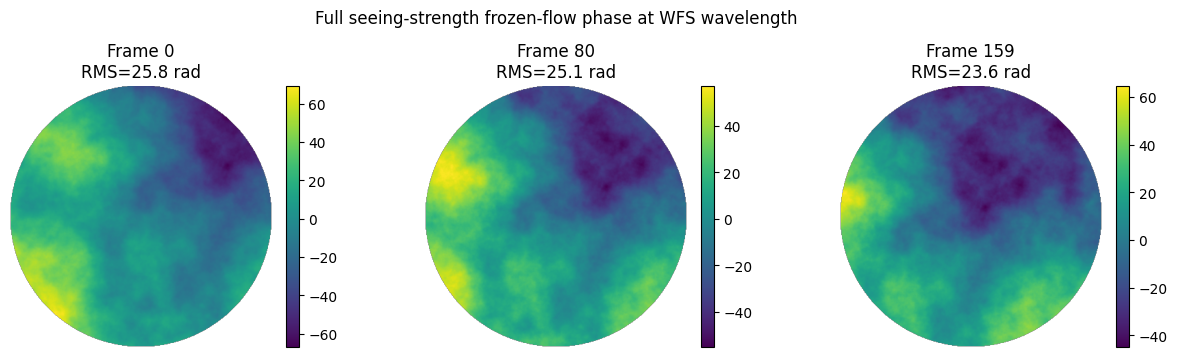

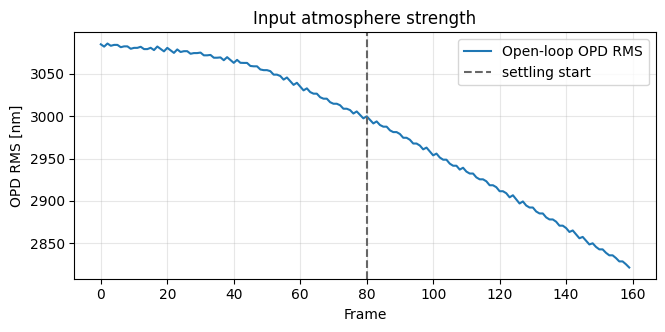

In [45]:
frames_to_show = [0, N_STEPS // 2, N_STEPS - 1]
fig, axes = plt.subplots(1, len(frames_to_show), figsize=(4.2 * len(frames_to_show), 3.6))
for ax, idx in zip(axes, frames_to_show):
    im = ax.imshow(np.where(pupil, phase_sequence[idx], np.nan), origin="lower")
    ax.set_title(f"Frame {idx}\nRMS={open_loop_rms[idx]:.1f} rad")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Full seeing-strength frozen-flow phase at WFS wavelength")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5, 3.2))
plt.plot(open_loop_opd_rms_nm, label="Open-loop OPD RMS")
plt.axvline(SETTLE_START, color="0.4", linestyle="--", label="settling start")
plt.xlabel("Frame")
plt.ylabel("OPD RMS [nm]")
plt.title("Input atmosphere strength")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 5. High-order SH-WFS slope model

This uses the average phase gradient in each valid subaperture. It is not a detector-spot image model, but it is the standard high-order linear SH-WFS model used for fast AO controller development.

Valid SH subapertures: 1804
SH signal length:      3608
SH slope estimator:    local plane fit inside each illuminated subaperture


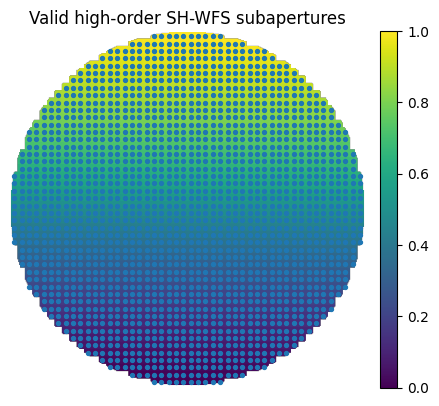

In [46]:
def make_sh_subaperture_labels(pupil_mask, n_subap, min_fill_fraction=0.45):
    """Assign each valid pupil pixel to a valid SH subaperture label."""
    n = pupil_mask.shape[0]
    edges = np.linspace(0, n, n_subap + 1).round().astype(int)
    labels = -np.ones_like(pupil_mask, dtype=int)
    centers = []
    label = 0
    for iy in range(n_subap):
        for ix in range(n_subap):
            y0, y1 = edges[iy], edges[iy + 1]
            x0, x1 = edges[ix], edges[ix + 1]
            local = np.zeros_like(pupil_mask, dtype=bool)
            local[y0:y1, x0:x1] = True
            local &= pupil_mask
            area = max(1, (y1 - y0) * (x1 - x0))
            fill = local.sum() / area
            if fill >= min_fill_fraction and local.sum() > 4:
                labels[local] = label
                centers.append(((ix + 0.5) / n_subap * 2 - 1, (iy + 0.5) / n_subap * 2 - 1))
                label += 1
    labels_valid = labels >= 0
    flat_labels = labels[labels_valid]
    counts = np.bincount(flat_labels, minlength=label).astype(float)
    return labels, labels_valid, flat_labels, counts, np.asarray(centers)


subap_labels, subap_valid_pixels, subap_flat_labels, subap_counts, subap_centers = make_sh_subaperture_labels(
    pupil,
    N_SUBAP,
    min_fill_fraction=0.45,
)
N_VALID_SUBAPS = len(subap_counts)

# Physical pupil coordinates in metres.  X,Y are normalized to pupil radius = 1,
# therefore x_m = X * D/2.
X_M = X * (TELESCOPE_DIAMETER_M / 2.0)
Y_M = Y * (TELESCOPE_DIAMETER_M / 2.0)

# Precompute a local plane-fit operator for each SH subaperture.
#
# This replaces the previous global np.gradient() implementation.  The previous
# version filled the outside-pupil region with zero before taking finite
# differences.  At the pupil edge this creates an artificial phase jump to zero,
# which then dominates the edge subaperture slopes under full seeing-strength
# turbulence.  A local least-squares plane fit uses only illuminated pixels inside
# each subaperture and is therefore much closer to a geometric SH-WFS slope.
subap_pixel_indices = []
subap_plane_pinv = []
flat_labels_full = subap_labels.ravel()
x_flat = X_M.ravel()
y_flat = Y_M.ravel()

for k in range(N_VALID_SUBAPS):
    idx = np.where(flat_labels_full == k)[0]
    subap_pixel_indices.append(idx)
    A_plane = np.column_stack([x_flat[idx], y_flat[idx], np.ones(len(idx))])
    subap_plane_pinv.append(np.linalg.pinv(A_plane))


def sh_geometric_slopes(phase, noise_std=0.0, seed=None):
    """High-order SH-WFS signal from local plane-fit slopes in each subaperture.

    Signal ordering is [sx_0, sy_0, sx_1, sy_1, ...] in rad/m.
    """
    flat = np.asarray(phase, dtype=float).ravel()
    signal = np.empty(2 * N_VALID_SUBAPS, dtype=float)

    for k, (idx, pinv) in enumerate(zip(subap_pixel_indices, subap_plane_pinv)):
        vals = flat[idx]
        if not np.all(np.isfinite(vals)):
            finite = np.isfinite(vals)
            if finite.sum() < 4:
                vals = np.zeros_like(vals)
            else:
                fill = np.mean(vals[finite])
                vals = np.where(finite, vals, fill)
        a_x, a_y, _ = pinv @ vals
        signal[2 * k] = a_x
        signal[2 * k + 1] = a_y

    if noise_std > 0.0:
        rng = np.random.default_rng(seed)
        signal = signal + rng.normal(0.0, noise_std, size=signal.shape)
    return signal


print(f"Valid SH subapertures: {N_VALID_SUBAPS}")
print(f"SH signal length:      {2*N_VALID_SUBAPS}")
print("SH slope estimator:    local plane fit inside each illuminated subaperture")

plt.figure(figsize=(5, 5))
plt.imshow(np.where(subap_labels >= 0, subap_labels, np.nan), origin="lower")
plt.scatter((subap_centers[:, 0] + 1) * 0.5 * (N_PUPIL - 1),
            (subap_centers[:, 1] + 1) * 0.5 * (N_PUPIL - 1),
            s=8)
plt.title("Valid high-order SH-WFS subapertures")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)
plt.show()


## 6. Actuator-grid deformable mirror with Gaussian influence functions

The DM correction space is represented by an actuator basis:

$$
\phi_\mathrm{DM}(x,y) = \sum_i c_i f_i(x,y),
$$

where each $f_i$ is a localized Gaussian influence function and $c_i$ is the actuator command.

This is the key upgrade from the previous low-order Zernike-modal correction: the controller now reconstructs **actuator commands**, not Zernike coefficients.

The current high-order run uses a 49 × 49 nominal actuator grid. Actuators whose centres lie slightly outside the illuminated pupil are retained as a guard ring. These guard-ring actuators are not science pixels, but they improve the continuous-face-sheet edge behaviour and reduce artificial pupil-boundary fitting errors.

In the current run the effective controlled basis contains:

```text
controlled actuators       = 2125
in-pupil actuators         = 1793
guard-ring actuators       = 332
maximum actuator radius    = 1.120 pupil radii
```

The influence functions are evaluated on the illuminated pupil, and the synthesized DM phase is piston-removed before computing the residual.

Effective controlled actuators:          2125
  in illuminated pupil:                  1793
  guard ring outside pupil:              332
Maximum actuator centre radius:          1.120 pupil radii
Actuator pitch:                          0.208 m
Influence sigma:                         0.70 pitch = 0.029 pupil-radius units


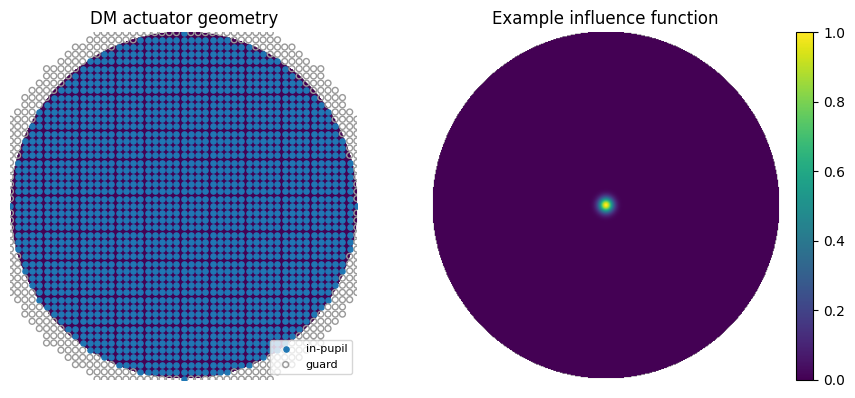

In [47]:
def make_gaussian_dm_influence_functions(X, Y, pupil_mask, n_act_across, coupling_sigma_pitch=0.65, edge_margin=1.12):
    """Generate Gaussian actuator influence functions on a square actuator grid.

    A small guard ring outside the illuminated pupil is included by default.
    This is intentional: without guard actuators the pupil edge becomes severely
    under-fitted and the ideal DM fitting floor is artificially high.  The
    influence functions are still evaluated only on the illuminated pupil.
    """
    positions_1d = np.linspace(-1.0, 1.0, n_act_across)
    pitch = positions_1d[1] - positions_1d[0]
    sigma = coupling_sigma_pitch * pitch

    influences = []
    positions = []
    radii = []
    is_guard = []

    for y0 in positions_1d:
        for x0 in positions_1d:
            r0 = float(np.hypot(x0, y0))
            if r0 <= edge_margin + 1e-12:
                influence = np.exp(-((X - x0)**2 + (Y - y0)**2) / (2.0 * sigma**2))
                influence *= pupil_mask
                peak = np.max(influence[pupil_mask])
                if peak <= 0:
                    continue
                influence = influence / peak
                # Do not remove piston from individual influence functions here.
                # The closed-loop residual and DM surface are piston-removed after
                # synthesis.  Mean-subtracting each actuator separately creates an
                # unnecessarily non-local actuator basis and can degrade fitting.
                influences.append(influence.astype(np.float32))
                positions.append((x0, y0))
                radii.append(r0)
                is_guard.append(r0 > 1.0)

    return (
        np.asarray(influences, dtype=np.float32),
        np.asarray(positions, dtype=float),
        pitch,
        sigma,
        np.asarray(radii, dtype=float),
        np.asarray(is_guard, dtype=bool),
    )


influence_functions, actuator_positions, actuator_pitch_norm, influence_sigma_norm, actuator_radii, actuator_is_guard = make_gaussian_dm_influence_functions(
    X,
    Y,
    pupil,
    n_act_across=N_ACT_ACROSS,
    coupling_sigma_pitch=DM_COUPLING_SIGMA_PITCH,
    edge_margin=DM_EDGE_MARGIN,
)
N_ACTUATORS = influence_functions.shape[0]

# Matrix form for fast DM synthesis on valid pupil pixels.
pupil_flat = pupil.ravel()
pupil_indices = np.where(pupil_flat)[0]
N_PUPIL_PIXELS = pupil_indices.size
influence_matrix = influence_functions.reshape(N_ACTUATORS, -1)[:, pupil_indices].T.astype(np.float32)


def dm_phase_from_commands(commands):
    """Synthesize a DM phase from actuator commands, in radians at the WFS wavelength."""
    commands = np.asarray(commands, dtype=float)
    flat = influence_matrix @ commands
    out = np.full((N_PUPIL, N_PUPIL), np.nan, dtype=float)
    out.ravel()[pupil_indices] = flat
    return remove_piston(out, pupil)


print(f"Effective controlled actuators:          {N_ACTUATORS}")
print(f"  in illuminated pupil:                  {(~actuator_is_guard).sum()}")
print(f"  guard ring outside pupil:              {actuator_is_guard.sum()}")
print(f"Maximum actuator centre radius:          {actuator_radii.max():.3f} pupil radii")
print(f"Actuator pitch:                          {TELESCOPE_DIAMETER_M/(N_ACT_ACROSS-1):.3f} m")
print(f"Influence sigma:                         {DM_COUPLING_SIGMA_PITCH:.2f} pitch = {influence_sigma_norm:.3f} pupil-radius units")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].imshow(np.where(pupil, 0.0, np.nan), origin="lower")

inside = ~actuator_is_guard
axes[0].scatter((actuator_positions[inside, 0] + 1) * 0.5 * (N_PUPIL - 1),
                (actuator_positions[inside, 1] + 1) * 0.5 * (N_PUPIL - 1),
                s=14, label="in-pupil")
if np.any(actuator_is_guard):
    axes[0].scatter((actuator_positions[actuator_is_guard, 0] + 1) * 0.5 * (N_PUPIL - 1),
                    (actuator_positions[actuator_is_guard, 1] + 1) * 0.5 * (N_PUPIL - 1),
                    s=18, facecolors="none", edgecolors="0.6", label="guard")
axes[0].set_title("DM actuator geometry")
axes[0].axis("off")
axes[0].legend(loc="lower right", fontsize=8)

# Show a central in-pupil actuator if available.
mid_candidates = np.where(~actuator_is_guard)[0]
mid = mid_candidates[len(mid_candidates) // 2] if len(mid_candidates) else N_ACTUATORS // 2
im = axes[1].imshow(np.where(pupil, influence_functions[mid], np.nan), origin="lower")
axes[1].set_title("Example influence function")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## 7. Poke-matrix calibration and TSVD command reconstructor

The interaction matrix is built by poking each DM actuator and measuring the corresponding high-order SH-WFS slope response. This gives the linearized actuator-to-slope matrix:

$$
A = \frac{\partial \mathbf{s}}{\partial \mathbf{c}},
$$

where $\mathbf{s}$ is the stacked SH-WFS slope vector and $\mathbf{c}$ is the actuator command vector.

The command reconstructor is obtained from a truncated singular-value decomposition:

$$
R = A^+_\mathrm{TSVD}.
$$

The TSVD cutoff controls how many singular modes are kept. Keeping too few modes underfits the phase. Keeping too many poorly conditioned modes amplifies unstable actuator commands. The adopted value,

```text
rcond = 2e-2
```

is chosen from the static closed-loop TSVD diagnostic scan later in the notebook.

For the current high-order run, the poke matrix has shape:

```text
SH-WFS signal length  = 3608
controlled actuators  = 2125
poke matrix shape     = 3608 × 2125
kept SVD channels     = 1942 / 2125
```

DM poke matrix shape:       (3608, 2125)
Kept SVD channels:          1942 / 2125
Condition number kept/full: 4.89e+01 / 1.41e+06


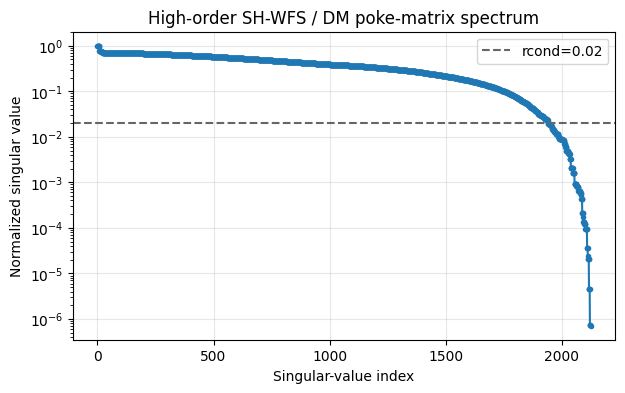

In [48]:
def build_dm_poke_matrix(influence_functions, poke_amp_rad=1.0):
    """Build SH-WFS response matrix for actuator pokes."""
    columns = []
    for influence in influence_functions:
        signal = sh_geometric_slopes(poke_amp_rad * influence, noise_std=0.0)
        columns.append(signal / poke_amp_rad)
    return np.column_stack(columns)

A_dm = build_dm_poke_matrix(influence_functions, poke_amp_rad=DM_POKE_AMP_RAD)
R_dm, S_dm, keep_dm = svd_reconstructor(A_dm, rcond=RECONSTRUCTOR_RCOND)

print(f"DM poke matrix shape:       {A_dm.shape}")
print(f"Kept SVD channels:          {keep_dm.sum()} / {len(keep_dm)}")
print(f"Condition number kept/full: {S_dm[0]/S_dm[keep_dm][-1]:.2e} / {S_dm[0]/S_dm[-1]:.2e}")

plt.figure(figsize=(7, 4))
plt.semilogy(S_dm / S_dm[0], "o-", markersize=3)
plt.axhline(RECONSTRUCTOR_RCOND, color="0.4", linestyle="--", label=f"rcond={RECONSTRUCTOR_RCOND:g}")
plt.xlabel("Singular-value index")
plt.ylabel("Normalized singular value")
plt.title("High-order SH-WFS / DM poke-matrix spectrum")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## 8. Optional ideal DM fitting floor estimate

This is computed only for selected frames to avoid making the notebook too slow. The closed loop itself is still run on every frame.

In [49]:
def fit_phase_with_dm_lstsq(phase, rcond=FIT_FLOOR_RCOND):
    """Best DM fit to a phase map using least squares on pupil pixels."""
    target = np.asarray(phase, dtype=float).ravel()[pupil_indices]
    target = target - np.mean(target)
    commands, *_ = np.linalg.lstsq(influence_matrix, target, rcond=rcond)
    fitted = dm_phase_from_commands(commands)
    residual = remove_piston(phase - fitted, pupil)
    return commands, fitted, residual

# Sampled ideal floor, not every frame.
N_FIT_SAMPLES = min(15, N_STEPS)
fit_sample_indices = np.unique(np.linspace(0, N_STEPS - 1, N_FIT_SAMPLES).round().astype(int))
ideal_fit_rms = []
for idx in fit_sample_indices:
    _, _, res_fit = fit_phase_with_dm_lstsq(phase_sequence[idx], rcond=FIT_FLOOR_RCOND)
    ideal_fit_rms.append(rms_masked(res_fit, pupil))
ideal_fit_rms = np.asarray(ideal_fit_rms)

print(f"Sampled ideal DM fitting floor: median={np.median(ideal_fit_rms):.3f} rad at WFS wavelength")
print(f"Fitting-floor least-squares rcond: {FIT_FLOOR_RCOND:g}")
print(f"Equivalent OPD floor:          {np.median(ideal_fit_rms) * WFS_WAVELENGTH_M/(2*np.pi) * 1e9:.1f} nm")

Sampled ideal DM fitting floor: median=0.810 rad at WFS wavelength
Fitting-floor least-squares rcond: 0.0003
Equivalent OPD floor:          96.7 nm


## 9. High-order closed-loop AO runner

The closed-loop controller measures the residual phase with the SH-WFS and updates the actuator commands with an integrator:

$$
\mathbf{c}_{k+1}
=
(1-\ell)\mathbf{c}_k
+
g R\,\mathbf{s}(\phi_{\mathrm{atm},k}-\phi_{\mathrm{DM},k}),
$$

where:

- $\mathbf{c}_k$ is the actuator command vector,
- $\ell$ is the optional command leak,
- $g$ is the loop gain,
- $R$ is the TSVD command reconstructor,
- $\mathbf{s}$ is the SH-WFS slope measurement,
- $\phi_{\mathrm{atm},k}$ is the incoming atmospheric phase,
- $\phi_{\mathrm{DM},k}$ is the DM correction phase.

The residual is always computed as the full seeing-strength atmospheric phase minus the actuator-DM correction:

$$
\phi_{\mathrm{res},k}
=
\phi_{\mathrm{atm},k}
-
\phi_{\mathrm{DM},k}.
$$

The main performance number reported below is the OPD RMS after the initial settling period.

In [50]:
def run_high_order_sh_ao(
    phase_sequence,
    gain=0.35,
    command_leak=0.001,
    measurement_noise_std=0.0,
    stroke_limit_rad=None,
    seed=123,
    store_correction_history=False,
):
    rng = np.random.default_rng(seed)
    n_frames = len(phase_sequence)
    commands = np.zeros(N_ACTUATORS, dtype=float)

    rms_before = np.zeros(n_frames)
    rms_after = np.zeros(n_frames)
    command_norm = np.zeros(n_frames)
    residual_after = []
    correction_history = [] if store_correction_history else None
    final_correction = None

    for t, phase_atm in enumerate(phase_sequence):
        correction_before = dm_phase_from_commands(commands)
        residual_before = remove_piston(phase_atm - correction_before, pupil)
        rms_before[t] = rms_masked(residual_before, pupil)

        signal = sh_geometric_slopes(
            residual_before,
            noise_std=measurement_noise_std,
            seed=int(rng.integers(0, 2**31 - 1)),
        )
        delta_commands = R_dm @ signal
        commands = (1.0 - command_leak) * commands + gain * delta_commands

        if stroke_limit_rad is not None:
            commands = np.clip(commands, -stroke_limit_rad, stroke_limit_rad)

        correction_after = dm_phase_from_commands(commands)
        residual = remove_piston(phase_atm - correction_after, pupil)
        rms_after[t] = rms_masked(residual, pupil)
        command_norm[t] = np.linalg.norm(commands)

        # Residual history is needed for after-settling metrics and PSFs.
        residual_after.append(residual.astype(np.float32))

        if store_correction_history:
            correction_history.append(correction_after.astype(np.float32))

        final_correction = correction_after

    result = {
        "rms_before": rms_before,
        "rms_after": rms_after,
        "residual_after": np.asarray(residual_after, dtype=np.float32),
        "command_norm": command_norm,
        "final_commands": commands.copy(),
        "correction_final": final_correction,
    }
    if store_correction_history:
        result["correction"] = np.asarray(correction_history, dtype=np.float32)
    return result


hist_ho = run_high_order_sh_ao(
    phase_sequence,
    gain=CONTROL_GAIN,
    command_leak=COMMAND_LEAK,
    measurement_noise_std=MEASUREMENT_NOISE_STD,
    stroke_limit_rad=DM_STROKE_LIMIT_RAD,
    seed=2026,
    store_correction_history=STORE_CORRECTION_HISTORY,
)

residual_opd_rms_nm = np.array([
    rms_masked(phase_to_opd_used(res, WFS_WAVELENGTH_M), pupil) * 1e9
    for res in hist_ho["residual_after"]
])

print("High-order AO loop complete.")
print(f"Open-loop median OPD RMS after settling:   {np.median(open_loop_opd_rms_nm[SETTLE_START:]):.1f} nm")
print(f"Closed-loop median OPD RMS after settling: {np.median(residual_opd_rms_nm[SETTLE_START:]):.1f} nm")
print(f"Correction factor:                         {np.median(open_loop_opd_rms_nm[SETTLE_START:]) / np.median(residual_opd_rms_nm[SETTLE_START:]):.1f}x")
print(f"Final command RMS:                         {np.std(hist_ho['final_commands']):.2f} rad")

High-order AO loop complete.
Open-loop median OPD RMS after settling:   2913.7 nm
Closed-loop median OPD RMS after settling: 134.8 nm
Correction factor:                         21.6x
Final command RMS:                         8.22 rad


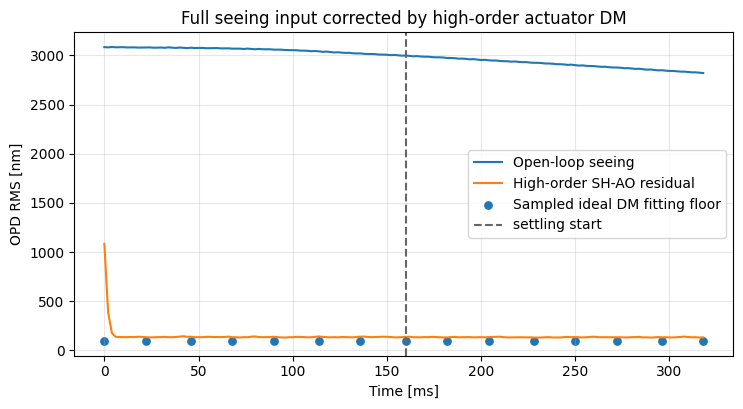

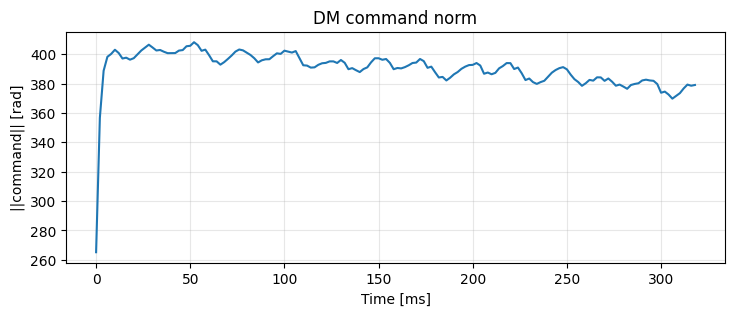

In [51]:
time_ms = np.arange(N_STEPS) * DT_S * 1000.0

plt.figure(figsize=(8.5, 4.2))
plt.plot(time_ms, open_loop_opd_rms_nm, label="Open-loop seeing")
plt.plot(time_ms, residual_opd_rms_nm, label="High-order SH-AO residual")
plt.scatter(fit_sample_indices * DT_S * 1000.0,
            ideal_fit_rms * WFS_WAVELENGTH_M/(2*np.pi) * 1e9,
            s=28,
            label="Sampled ideal DM fitting floor")
plt.axvline(SETTLE_START * DT_S * 1000.0, color="0.4", linestyle="--", label="settling start")
plt.xlabel("Time [ms]")
plt.ylabel("OPD RMS [nm]")
plt.title("Full seeing input corrected by high-order actuator DM")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8.5, 3.0))
plt.plot(time_ms, hist_ho["command_norm"])
plt.xlabel("Time [ms]")
plt.ylabel("||command|| [rad]")
plt.title("DM command norm")
plt.grid(alpha=0.3)
plt.show()

## 10. Residual maps and PSF stamps

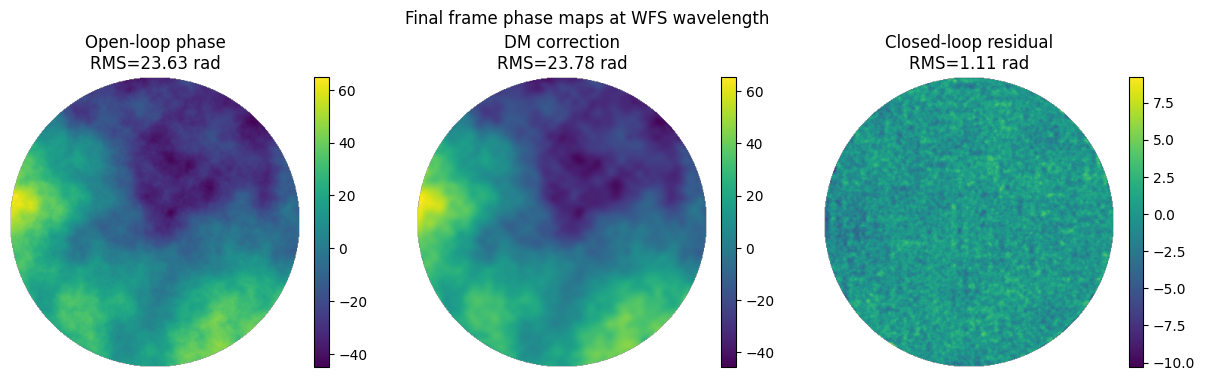

Final-frame OPD RMS:
  Open-loop:    2821.2 nm
  Closed-loop:  133.1 nm


In [52]:
idx_final = N_STEPS - 1
open_phase_final = phase_sequence[idx_final]
correction_final = hist_ho["correction_final"]
residual_final = hist_ho["residual_after"][idx_final]

open_opd_final = phase_to_opd_used(open_phase_final, WFS_WAVELENGTH_M)
residual_opd_final = phase_to_opd_used(residual_final, WFS_WAVELENGTH_M)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.8))
items = [
    (open_phase_final, "Open-loop phase"),
    (correction_final, "DM correction"),
    (residual_final, "Closed-loop residual"),
]
for ax, (arr, title) in zip(axes, items):
    im = ax.imshow(np.where(pupil, arr, np.nan), origin="lower")
    ax.set_title(f"{title}\nRMS={rms_masked(arr, pupil):.2f} rad")
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Final frame phase maps at WFS wavelength")
plt.tight_layout()
plt.show()

print("Final-frame OPD RMS:")
print(f"  Open-loop:    {rms_masked(open_opd_final, pupil)*1e9:.1f} nm")
print(f"  Closed-loop:  {rms_masked(residual_opd_final, pupil)*1e9:.1f} nm")

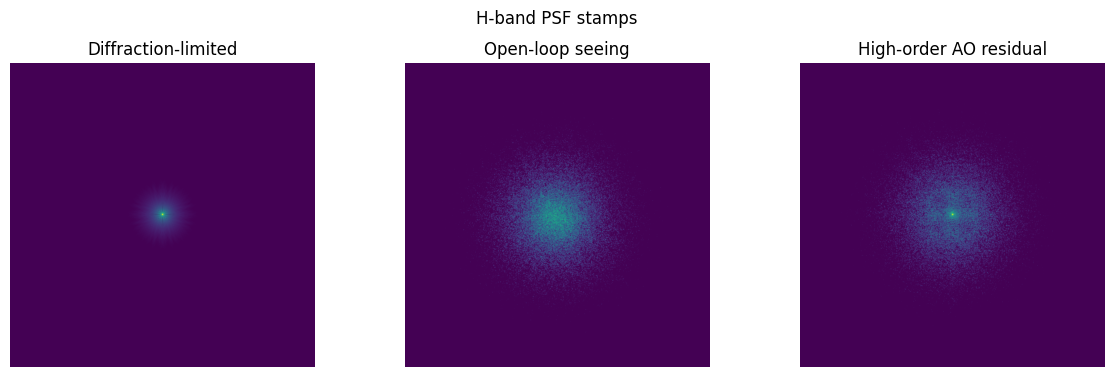

In [53]:
def pad_to_shape(arr, target_n):
    arr = np.asarray(arr)
    n = arr.shape[0]
    out = np.zeros((target_n, target_n), dtype=arr.dtype)
    c = target_n // 2
    h = n // 2
    out[c - h:c - h + n, c - h:c - h + n] = arr
    return out


def psf_from_opd(opd, pupil_mask, wavelength_m, pad_factor=4):
    """Monochromatic PSF from OPD map. Returns normalized PSF and ideal PSF."""
    phase = 2.0 * np.pi * np.nan_to_num(opd, nan=0.0) / wavelength_m
    complex_pupil = pupil_mask.astype(complex) * np.exp(1j * phase)
    ideal_pupil = pupil_mask.astype(complex)
    n_pad = int(pad_factor * pupil_mask.shape[0])
    E = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(pad_to_shape(complex_pupil, n_pad))))
    E0 = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(pad_to_shape(ideal_pupil, n_pad))))
    psf = np.abs(E)**2
    psf0 = np.abs(E0)**2
    psf /= np.sum(psf)
    psf0 /= np.sum(psf0)
    return psf, psf0


def strehl_from_opd(opd, pupil_mask, wavelength_m, pad_factor=4):
    psf, psf0 = psf_from_opd(opd, pupil_mask, wavelength_m, pad_factor=pad_factor)
    return float(np.max(psf) / np.max(psf0))


def angular_pixel_scale_mas(wavelength_m, telescope_diameter_m, pad_factor):
    # Pupil diameter is sampled by N pixels and padded by pad_factor, so image sampling is lambda/D/pad_factor.
    return wavelength_m / telescope_diameter_m / pad_factor * RAD_TO_MAS


def psf_shape_metrics(opd, pupil_mask, wavelength_m, telescope_diameter_m, pad_factor=4):
    psf, psf0 = psf_from_opd(opd, pupil_mask, wavelength_m, pad_factor=pad_factor)
    strehl = float(np.max(psf) / np.max(psf0))
    n = psf.shape[0]
    yy, xx = np.indices(psf.shape)
    cy = cx = n // 2
    r_pix = np.sqrt((xx - cx)**2 + (yy - cy)**2)
    pix_mas = angular_pixel_scale_mas(wavelength_m, telescope_diameter_m, pad_factor)
    r_mas = r_pix * pix_mas

    # FWHM: diameter of equivalent radius where radial pixels remain above half maximum.
    halfmax = 0.5 * np.max(psf)
    above = psf >= halfmax
    if np.any(above):
        fwhm_mas = 2.0 * np.max(r_mas[above])
    else:
        fwhm_mas = np.nan

    order = np.argsort(r_mas.ravel())
    r_sorted = r_mas.ravel()[order]
    e_sorted = np.cumsum(psf.ravel()[order])
    ee50 = float(np.interp(0.50, e_sorted, r_sorted))
    ee80 = float(np.interp(0.80, e_sorted, r_sorted))
    return {"strehl": strehl, "fwhm_mas": float(fwhm_mas), "ee50_mas": ee50, "ee80_mas": ee80}


SCIENCE_BAND_FOR_STAMPS = "H"
lam_stamp = SCIENCE_BANDS[SCIENCE_BAND_FOR_STAMPS]
psf_open, psf_ideal = psf_from_opd(open_opd_final, pupil, lam_stamp, pad_factor=PSF_PAD_FACTOR)
psf_res, _ = psf_from_opd(residual_opd_final, pupil, lam_stamp, pad_factor=PSF_PAD_FACTOR)

vmax = psf_ideal.max()
vmin = vmax * 1e-6
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, img, title in [
    (axes[0], psf_ideal, "Diffraction-limited"),
    (axes[1], psf_open, "Open-loop seeing"),
    (axes[2], psf_res, "High-order AO residual"),
]:
    im = ax.imshow(np.maximum(img, vmin), origin="lower", norm=plt.matplotlib.colors.LogNorm(vmin=vmin, vmax=vmax))
    ax.set_title(title)
    ax.axis("off")
plt.suptitle(f"{SCIENCE_BAND_FOR_STAMPS}-band PSF stamps")
plt.tight_layout()
plt.show()

## 11. Science metrics after settling

After the loop has settled, the residual WFE is converted into NIR image-quality metrics for the J, H, and K bands.

The reported metrics include:

- median OPD RMS after settling,
- percentile range of the residual OPD RMS,
- Marechal-approximation Strehl ratio,
- final-frame PSF Strehl,
- FWHM in milliarcseconds,
- EE50 and EE80 encircled-energy radii.

These metrics are intended as PSF-level AO performance diagnostics. They are not a full instrument-throughput, detector, sky-background, or exposure-time calculation.

In [54]:
def summarize_sequence_metrics(residual_phase_sequence, label):
    rows = []
    tail = residual_phase_sequence[SETTLE_START:]
    opd_rms_nm = np.array([
        rms_masked(phase_to_opd_used(res, WFS_WAVELENGTH_M), pupil) * 1e9
        for res in tail
    ])
    for band, lam in SCIENCE_BANDS.items():
        strehls = []
        for res in tail:
            opd = phase_to_opd_used(res, WFS_WAVELENGTH_M)
            strehls.append(strehl_from_opd(opd, pupil, lam, pad_factor=2))
        strehls = np.asarray(strehls)
        rows.append({
            "case": label,
            "band": band,
            "lambda_um": lam * 1e6,
            "median_opd_rms_nm": float(np.median(opd_rms_nm)),
            "p10_opd_rms_nm": float(np.percentile(opd_rms_nm, 10)),
            "p90_opd_rms_nm": float(np.percentile(opd_rms_nm, 90)),
            "median_strehl": float(np.median(strehls)),
            "p10_strehl": float(np.percentile(strehls, 10)),
            "p90_strehl": float(np.percentile(strehls, 90)),
        })
    return rows

summary_rows = []
summary_rows += summarize_sequence_metrics(phase_sequence, "Open-loop seeing")
summary_rows += summarize_sequence_metrics(hist_ho["residual_after"], "High-order SH-AO residual")

if pd is not None:
    summary_df = pd.DataFrame(summary_rows)
    display(summary_df)
else:
    for row in summary_rows:
        print(row)

,case,band,lambda_um,median_opd_rms_nm,p10_opd_rms_nm,p90_opd_rms_nm,median_strehl,p10_strehl,p90_strehl
0,Open-loop seeing,J,1.25,2913.743940,2842.260278,2981.424333,0.004430,0.004231,0.004566
1,Open-loop seeing,H,1.65,2913.743940,2842.260278,2981.424333,0.007960,0.007442,0.008680
2,Open-loop seeing,K,2.20,2913.743940,2842.260278,2981.424333,0.013669,0.013141,0.015082
3,High-order SH-AO residual,J,1.25,134.782236,132.642571,138.333006,0.639137,0.623664,0.648976
4,High-order SH-AO residual,H,1.65,134.782236,132.642571,138.333006,0.771765,0.760910,0.778577
5,High-order SH-AO residual,K,2.20,134.782236,132.642571,138.333006,0.863601,0.856798,0.867830


In [55]:
metric_rows = []
for case_name, opd in [
    ("Open-loop seeing", open_opd_final),
    ("High-order SH-AO residual", residual_opd_final),
]:
    for band, lam in SCIENCE_BANDS.items():
        metrics = psf_shape_metrics(
            opd,
            pupil,
            wavelength_m=lam,
            telescope_diameter_m=TELESCOPE_DIAMETER_M,
            pad_factor=PSF_PAD_FACTOR,
        )
        metric_rows.append({
            "case": case_name,
            "band": band,
            "lambda_um": lam * 1e6,
            "strehl": metrics["strehl"],
            "fwhm_mas": metrics["fwhm_mas"],
            "ee50_mas": metrics["ee50_mas"],
            "ee80_mas": metrics["ee80_mas"],
        })

if pd is not None:
    psf_metric_df = pd.DataFrame(metric_rows)
    display(psf_metric_df)
else:
    for row in metric_rows:
        print(row)

,case,band,lambda_um,strehl,fwhm_mas,ee50_mas,ee80_mas
0,Open-loop seeing,J,1.25,0.004355,1083.198148,605.526173,1042.265089
1,Open-loop seeing,H,1.65,0.007506,1071.521983,560.395021,984.370708
2,Open-loop seeing,K,2.20,0.016449,903.586675,525.536748,925.817414
3,High-order SH-AO residual,J,1.25,0.644789,28.826410,20.383350,695.577154
4,High-order SH-AO residual,H,1.65,0.775993,38.050861,23.449499,274.388663
5,High-order SH-AO residual,K,2.20,0.866444,45.378300,25.367241,104.591814


## 12. Simple NIR field-performance estimate

This section gives a simple analytic estimate of off-axis Strehl degradation using an anisoplanatic roll-off:

$$
S(\theta) = S_0 \exp[-(\theta/\theta_0)^{5/3}].
$$

Here $S_0$ is the on-axis Strehl from the high-order AO residual, and $\theta_0$ is a wavelength-scaled isoplanatic angle.

This is **not** a tomographic AO simulation. It does not model multi-layer turbulence, guide-star geometry, MCAO, MOAO, GLAO, LGS cone effect, or field-dependent wavefront reconstruction. It is included only to connect the on-axis PSF result to a first-order NIR field-performance estimate.

In [56]:
def theta0_for_band(theta0_h_arcsec, wavelength_m):
    return theta0_h_arcsec * (wavelength_m / SCIENCE_BANDS["H"]) ** (6.0 / 5.0)


def anisoplanatic_strehl_rolloff(s0, theta_arcsec, theta0_arcsec):
    return s0 * np.exp(-float(theta_arcsec / theta0_arcsec) ** (5.0 / 3.0))

field_rows = []
residual_tail = hist_ho["residual_after"][SETTLE_START:]
for band, lam in SCIENCE_BANDS.items():
    on_axis = []
    for res in residual_tail:
        opd = phase_to_opd_used(res, WFS_WAVELENGTH_M)
        on_axis.append(strehl_from_opd(opd, pupil, lam, pad_factor=2))
    s0 = float(np.median(on_axis))
    theta0 = theta0_for_band(THETA0_H_ARCSEC, lam)
    for theta in FIELD_OFFSETS_ARCSEC:
        field_rows.append({
            "case": "High-order SH-AO residual",
            "band": band,
            "field_radius_arcsec": float(theta),
            "theta0_arcsec": float(theta0),
            "strehl_field": float(anisoplanatic_strehl_rolloff(s0, theta, theta0)),
        })

if pd is not None:
    field_df = pd.DataFrame(field_rows)
    display(field_df)
else:
    for row in field_rows:
        print(row)

,case,band,field_radius_arcsec,theta0_arcsec,strehl_field
0,High-order SH-AO residual,J,0.0,17.916422,0.639137
1,High-order SH-AO residual,J,5.0,17.916422,0.567330
2,High-order SH-AO residual,J,10.0,17.916422,0.437795
3,High-order SH-AO residual,J,15.0,17.916422,0.303814
4,High-order SH-AO residual,J,20.0,17.916422,0.192265
5,High-order SH-AO residual,H,0.0,25.000000,0.771765
6,High-order SH-AO residual,H,5.0,25.000000,0.720742
7,High-order SH-AO residual,H,10.0,25.000000,0.621121
8,High-order SH-AO residual,H,15.0,25.000000,0.503635
9,High-order SH-AO residual,H,20.0,25.000000,0.387324


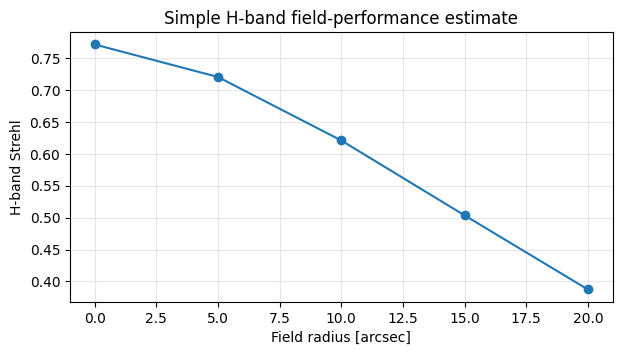

In [57]:
if pd is not None:
    h_df = field_df[field_df["band"] == "H"]
    plt.figure(figsize=(7, 3.5))
    plt.plot(h_df["field_radius_arcsec"], h_df["strehl_field"], "o-")
    plt.xlabel("Field radius [arcsec]")
    plt.ylabel("H-band Strehl")
    plt.title("Simple H-band field-performance estimate")
    plt.grid(alpha=0.3)
    plt.show()

## 13. Controller-parameter diagnostics

The following cells check whether the adopted TSVD cutoff and loop gain are reasonable.

These diagnostic scans are included as reproducibility checks for the chosen controller parameters:

```text
RECONSTRUCTOR_RCOND = 2e-2
CONTROL_GAIN        = 0.65
```

The static TSVD scan tests how the residual changes when more or fewer singular modes are kept. The result shows a useful optimum region around `rcond ≈ 0.015–0.03`. More permissive cutoffs retain additional low-singular-value modes, but these modes are poorly conditioned and increase the command norm without improving the residual.

The dynamic gain scan then tests the closed-loop residual over the frozen-flow phase sequence. The residual reaches a broad minimum for gains around 0.55–0.75, so `gain = 0.65` is chosen as a conservative value inside the stable performance plateau.

These scans should be interpreted as controller-tuning diagnostics for the current simplified, noiseless SH-WFS benchmark. They are not a replacement for a full AO error budget.

Static final OPD RMS:       135.6 nm
Static median tail OPD RMS: 135.6 nm
Ideal DM fitting floor:     96.7 nm


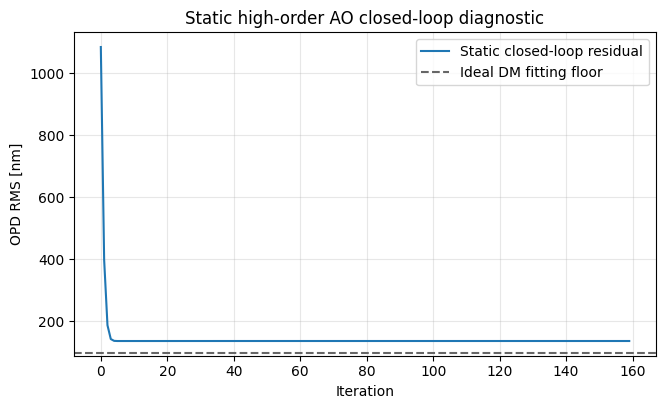

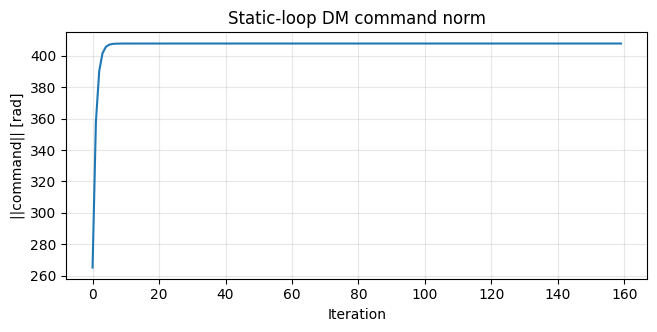

In [58]:
# ------------------------------------------------------------
# Static high-order closed-loop diagnostic
# ------------------------------------------------------------
# Purpose:
#   Check the static residual obtained with the currently adopted TSVD
#   reconstructor. This separates the static DM/WFS/reconstructor floor
#   from the dynamic frozen-flow closed-loop residual.
#
# After a clean Run All, this diagnostic should use:
#   RECONSTRUCTOR_RCOND = 2e-2
#   CONTROL_GAIN        = 0.65
#
# run_high_order_sh_ao() uses the global R_dm in this notebook.

static_phase = phase_sequence[0]
static_sequence = np.repeat(static_phase[None, :, :], 160, axis=0)

hist_static = run_high_order_sh_ao(
    static_sequence,
    gain=CONTROL_GAIN,
    command_leak=COMMAND_LEAK,
    measurement_noise_std=MEASUREMENT_NOISE_STD,
    stroke_limit_rad=DM_STROKE_LIMIT_RAD,
    seed=2027,
    store_correction_history=False,
)

static_rms_rad = np.asarray(hist_static["rms_after"])
static_rms_nm = static_rms_rad * WFS_WAVELENGTH_M / (2.0 * np.pi) * 1e9

ideal_floor_nm = np.median(ideal_fit_rms) * WFS_WAVELENGTH_M / (2.0 * np.pi) * 1e9

print(f"Static final OPD RMS:       {static_rms_nm[-1]:.1f} nm")
print(f"Static median tail OPD RMS: {np.median(static_rms_nm[-50:]):.1f} nm")
print(f"Ideal DM fitting floor:     {ideal_floor_nm:.1f} nm")

plt.figure(figsize=(7.5, 4.2))
plt.plot(static_rms_nm, label="Static closed-loop residual")
plt.axhline(ideal_floor_nm, color="0.4", linestyle="--", label="Ideal DM fitting floor")
plt.xlabel("Iteration")
plt.ylabel("OPD RMS [nm]")
plt.title("Static high-order AO closed-loop diagnostic")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7.5, 3.2))
plt.plot(hist_static["command_norm"])
plt.xlabel("Iteration")
plt.ylabel("||command|| [rad]")
plt.title("Static-loop DM command norm")
plt.grid(alpha=0.3)
plt.show()

,rcond,kept_modes,static_tail_rms_nm,static_final_rms_nm,final_command_norm
0,0.0100,1985,139.233448,139.233448,433.811240
1,0.0050,2019,154.663572,154.663572,493.894926
2,0.0030,2039,165.059271,165.059271,546.764926
3,0.0020,2047,173.280524,173.280524,681.849586
4,0.0010,2055,178.918986,178.918986,777.520256
5,0.0007,2071,235.778739,235.778739,1412.802872
6,0.0005,2084,341.805130,341.805130,2054.314469
7,0.0003,2088,464.963202,464.963202,2753.070915


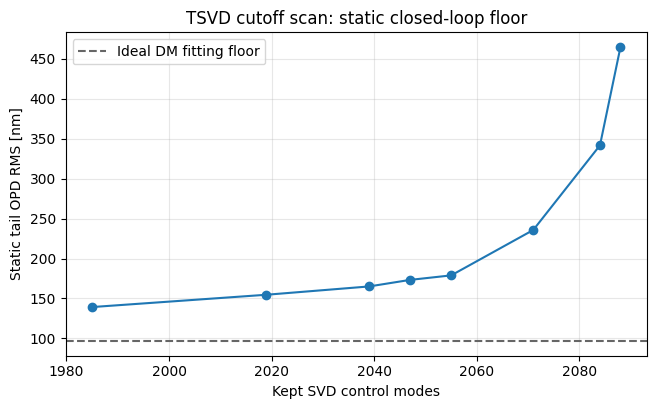

In [37]:
# ------------------------------------------------------------
# TSVD rcond scan on the static diagnostic
# ------------------------------------------------------------
# This scan tests whether the static residual is limited by underfitting
# at large rcond or by poorly conditioned command amplification at small rcond.

U_dm, S_dm, Vt_dm = np.linalg.svd(A_dm, full_matrices=False)

def make_reconstructor_from_svd(U, S, Vt, rcond):
    cutoff = rcond * S[0]
    keep = S > cutoff
    R = (Vt[keep].T / S[keep]) @ U[:, keep].T
    return R, keep

static_phase = phase_sequence[0]
static_sequence = np.repeat(static_phase[None, :, :], 160, axis=0)

rcond_list = [1e-2, 5e-3, 3e-3, 2e-3, 1e-3, 7e-4, 5e-4, 3e-4]
rcond_results = []

R_dm_original = R_dm

for rc in rcond_list:
    R_test, keep_test = make_reconstructor_from_svd(U_dm, S_dm, Vt_dm, rc)
    
    # run_high_order_sh_ao() uses the global R_dm in this notebook
    R_dm = R_test
    
    hist = run_high_order_sh_ao(
        static_sequence,
        gain=CONTROL_GAIN,
        command_leak=0.0,
        measurement_noise_std=0.0,
        stroke_limit_rad=np.inf,
        seed=3001,
        store_correction_history=False,
    )
    
    rms_rad = np.asarray(hist["rms_after"])
    rms_nm = rms_rad * WFS_WAVELENGTH_M / (2.0 * np.pi) * 1e9
    
    rcond_results.append({
        "rcond": rc,
        "kept_modes": int(np.sum(keep_test)),
        "static_tail_rms_nm": float(np.median(rms_nm[-50:])),
        "static_final_rms_nm": float(rms_nm[-1]),
        "final_command_norm": float(hist["command_norm"][-1]),
    })

# restore original reconstructor
R_dm = R_dm_original

rcond_df = pd.DataFrame(rcond_results)
display(rcond_df)

plt.figure(figsize=(7.5, 4.2))
plt.plot(rcond_df["kept_modes"], rcond_df["static_tail_rms_nm"], marker="o")
plt.axhline(ideal_floor_nm, color="0.4", linestyle="--", label="Ideal DM fitting floor")
plt.xlabel("Kept SVD control modes")
plt.ylabel("Static tail OPD RMS [nm]")
plt.title("TSVD cutoff scan: static closed-loop floor")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

,rcond,kept_modes,static_tail_rms_nm,static_final_rms_nm,final_command_norm
0,0.100,1753,2613.009964,2613.009964,227.079129
1,0.070,1810,2615.150163,2615.150163,232.108497
2,0.050,1857,137.955804,137.955804,393.177683
3,0.030,1911,137.239111,137.239111,400.531356
4,0.020,1942,135.645505,135.645505,407.878372
5,0.015,1958,135.829085,135.829085,412.750968
6,0.010,1985,139.233448,139.233448,433.811240
7,0.007,2011,148.857980,148.857980,467.436937
8,0.005,2019,154.663572,154.663572,493.894926
9,0.003,2039,165.059271,165.059271,546.764926


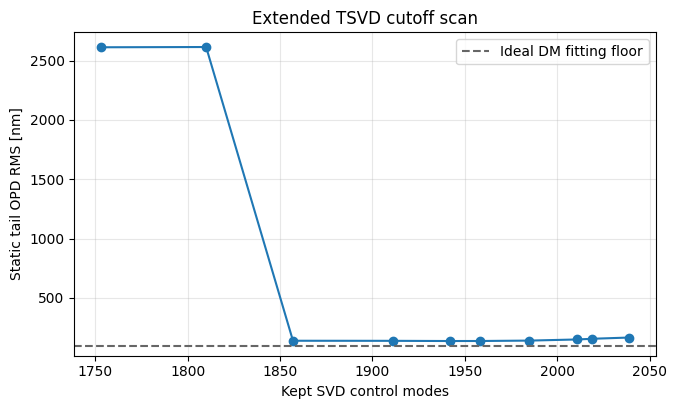

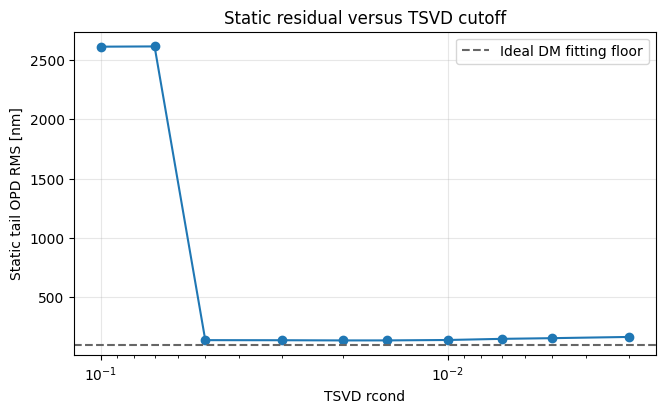

In [39]:
# ------------------------------------------------------------
# Extended TSVD rcond scan
# ------------------------------------------------------------
# The first scan shows that very permissive cutoffs can degrade the residual
# by retaining poorly conditioned low-singular-value modes.
# This extended scan checks stricter cutoffs and identifies the useful
# performance plateau around rcond ≈ 0.015–0.03.

rcond_list = [
    1e-1,
    7e-2,
    5e-2,
    3e-2,
    2e-2,
    1.5e-2,
    1e-2,
    7e-3,
    5e-3,
    3e-3,
]

rcond_results = []

R_dm_original = R_dm

for rc in rcond_list:
    R_test, keep_test = make_reconstructor_from_svd(U_dm, S_dm, Vt_dm, rc)

    # run_high_order_sh_ao() uses global R_dm
    R_dm = R_test

    hist = run_high_order_sh_ao(
        static_sequence,
        gain=CONTROL_GAIN,
        command_leak=0.0,
        measurement_noise_std=0.0,
        stroke_limit_rad=np.inf,
        seed=3002,
        store_correction_history=False,
    )

    rms_rad = np.asarray(hist["rms_after"])
    rms_nm = rms_rad * WFS_WAVELENGTH_M / (2.0 * np.pi) * 1e9

    rcond_results.append({
        "rcond": rc,
        "kept_modes": int(np.sum(keep_test)),
        "static_tail_rms_nm": float(np.median(rms_nm[-50:])),
        "static_final_rms_nm": float(rms_nm[-1]),
        "final_command_norm": float(hist["command_norm"][-1]),
    })

R_dm = R_dm_original

rcond_df = pd.DataFrame(rcond_results).sort_values("rcond", ascending=False)
display(rcond_df)

plt.figure(figsize=(7.5, 4.2))
plt.plot(rcond_df["kept_modes"], rcond_df["static_tail_rms_nm"], marker="o")
plt.axhline(ideal_floor_nm, color="0.4", linestyle="--", label="Ideal DM fitting floor")
plt.xlabel("Kept SVD control modes")
plt.ylabel("Static tail OPD RMS [nm]")
plt.title("Extended TSVD cutoff scan")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(7.5, 4.2))
plt.semilogx(rcond_df["rcond"], rcond_df["static_tail_rms_nm"], marker="o")
plt.gca().invert_xaxis()
plt.axhline(ideal_floor_nm, color="0.4", linestyle="--", label="Ideal DM fitting floor")
plt.xlabel("TSVD rcond")
plt.ylabel("Static tail OPD RMS [nm]")
plt.title("Static residual versus TSVD cutoff")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

,gain,dynamic_tail_rms_nm,dynamic_final_rms_nm,final_command_norm
0,0.25,165.778236,169.013853,366.206393
1,0.35,145.042803,146.789586,371.462576
2,0.45,137.370812,138.008280,374.998528
3,0.55,134.868367,134.421948,377.408189
4,0.65,134.782236,133.079023,379.125748
5,0.75,134.822771,132.798437,380.415012
6,0.85,135.366852,133.026323,381.409335
7,0.95,135.896291,133.439588,382.153624


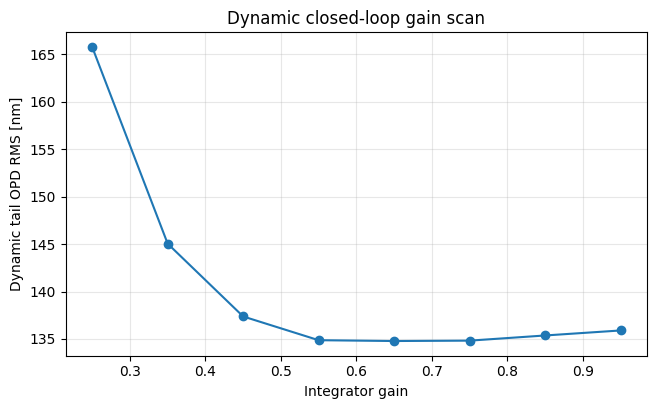

In [41]:
# ------------------------------------------------------------
# Dynamic gain scan after choosing the best TSVD cutoff
# ------------------------------------------------------------

# Rebuild reconstructor with best rcond
BEST_RCOND = 2e-2
R_dm, keep_dm = make_reconstructor_from_svd(U_dm, S_dm, Vt_dm, BEST_RCOND)

gain_list = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95]
gain_results = []

for g in gain_list:
    hist = run_high_order_sh_ao(
        phase_sequence,
        gain=g,
        command_leak=COMMAND_LEAK,
        measurement_noise_std=MEASUREMENT_NOISE_STD,
        stroke_limit_rad=DM_STROKE_LIMIT_RAD,
        seed=4101,
        store_correction_history=False,
    )

    rms_rad = np.asarray(hist["rms_after"])
    rms_nm = rms_rad * WFS_WAVELENGTH_M / (2.0 * np.pi) * 1e9

    gain_results.append({
        "gain": g,
        "dynamic_tail_rms_nm": float(np.median(rms_nm[SETTLE_START:])),
        "dynamic_final_rms_nm": float(rms_nm[-1]),
        "final_command_norm": float(hist["command_norm"][-1]),
    })

gain_df = pd.DataFrame(gain_results)
display(gain_df)

plt.figure(figsize=(7.5, 4.2))
plt.plot(gain_df["gain"], gain_df["dynamic_tail_rms_nm"], marker="o")
plt.xlabel("Integrator gain")
plt.ylabel("Dynamic tail OPD RMS [nm]")
plt.title("Dynamic closed-loop gain scan")
plt.grid(alpha=0.3)
plt.show()

# Keep the global controller state consistent with the adopted notebook setting.
RECONSTRUCTOR_RCOND = BEST_RCOND
CONTROL_GAIN = 0.65
R_dm, keep_dm = make_reconstructor_from_svd(U_dm, S_dm, Vt_dm, RECONSTRUCTOR_RCOND)

print(f"Adopted final controller setting: rcond={RECONSTRUCTOR_RCOND:g}, gain={CONTROL_GAIN:.2f}")

## 14. Interpretation notes

This notebook is intended as a **high-order AO / NIR PSF performance demonstrator**, not as a complete observatory AO simulator.

The current main run demonstrates that a higher-order actuator-space SH-AO loop can strongly suppress a full seeing-strength frozen-flow phase sequence for a 10 m-class telescope.

Key modelling choices in this version:

- the main run uses `AO_QUALITY_MODE = "extreme"`;
- the sampling is `N_SUBAP = 48`, `N_ACT_ACROSS = 49`, and `N_PUPIL = 384`;
- the input atmosphere is a full seeing-strength frozen-flow phase sequence for a 10 m aperture;
- the frozen-flow phase sheet is rectangular and unmasked; the circular telescope pupil is applied only after each moving crop;
- the SH-WFS uses local geometric slope fits inside illuminated subapertures;
- the DM is an actuator-grid model with overlapping Gaussian influence functions;
- a guard-actuator ring is included around the illuminated pupil to improve edge fitting;
- the interaction matrix is calibrated by actuator pokes;
- the controller reconstructs actuator commands, not Zernike coefficients;
- the TSVD cutoff is selected from a static rcond scan;
- the loop gain is selected from a dynamic gain scan;
- the final PSF metrics are computed from the full residual phase after high-order correction.

For the current clean high-order run, the representative results are:

```text
open-loop median OPD RMS after settling    ≈ 2914 nm
closed-loop median OPD RMS after settling  ≈ 135 nm
correction factor                          ≈ 22×
```

The corresponding NIR Strehl ratios are approximately:

```text
J band  ≈ 0.64
H band  ≈ 0.77
K band  ≈ 0.86
```

This is a useful portfolio-level result because it connects AO control choices directly to science-facing PSF metrics such as Strehl, FWHM, EE50, and EE80.

Remaining limitations:

- the SH-WFS model is geometric slope sensing, not detector spot-image centroiding;
- there is no photon noise, read noise, centroiding error, or detector nonlinearity;
- there is no temporal delay, vibration, wind-shake, or full servo-lag error budget;
- there is no multi-layer atmosphere or tomographic reconstruction;
- anisoplanatism is included only as a simple analytic field roll-off, not as a true field-dependent AO simulation;
- the DM influence functions are analytic Gaussian approximations, not measured DM calibration data;
- there is no LGS cone effect, NCPA, chromaticity, throughput model, sky background, or science-camera noise;
- the PWFS comparison is not included in this notebook because high-order detector-level PWFS calibration should be treated as a separate heavy benchmark.

These results should be interpreted as a clean-model high-order AO demonstration. They illustrate numerical trends under the stated assumptions, not calibrated predictions for a telescope or instrument.

The most useful next extension is detector-level WFS measurement physics together with temporal delay, photon/read noise, multi-layer turbulence, and a more complete AO error budget.